In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Membaca dataset 'diabetes.csv' yang sudah ditaruh di folder yang sama
df = pd.read_csv('diabetes.csv')

# Menampilkan 5 data teratas untuk memastikan data sukses terbaca
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Mengubah nilai 0 yang tidak logis (Glukosa, Tekanan Darah, dll) menjadi NaN
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in invalid_zero_cols:
    df[col] = df[col].replace(0, np.nan)

# Mengisi nilai NaN tersebut menggunakan nilai median berdasarkan kategori Outcome (0 atau 1)
for col in invalid_zero_cols:
    df[col] = df[col].fillna(df.groupby('Outcome')[col].transform('median'))

print("Data cleaning selesai! Semua nilai kosong/tidak logis sudah diperbaiki.")

Data cleaning selesai! Semua nilai kosong/tidak logis sudah diperbaiki.


C:\Users\ACER\AppData\Local\Temp\ipykernel_3012\64077907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_3012\64077907.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set1')
C:\Users\ACER\AppData\Local\Temp\ipykernel_3012\64077907.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y='BMI', data=df, palette='Pastel1')


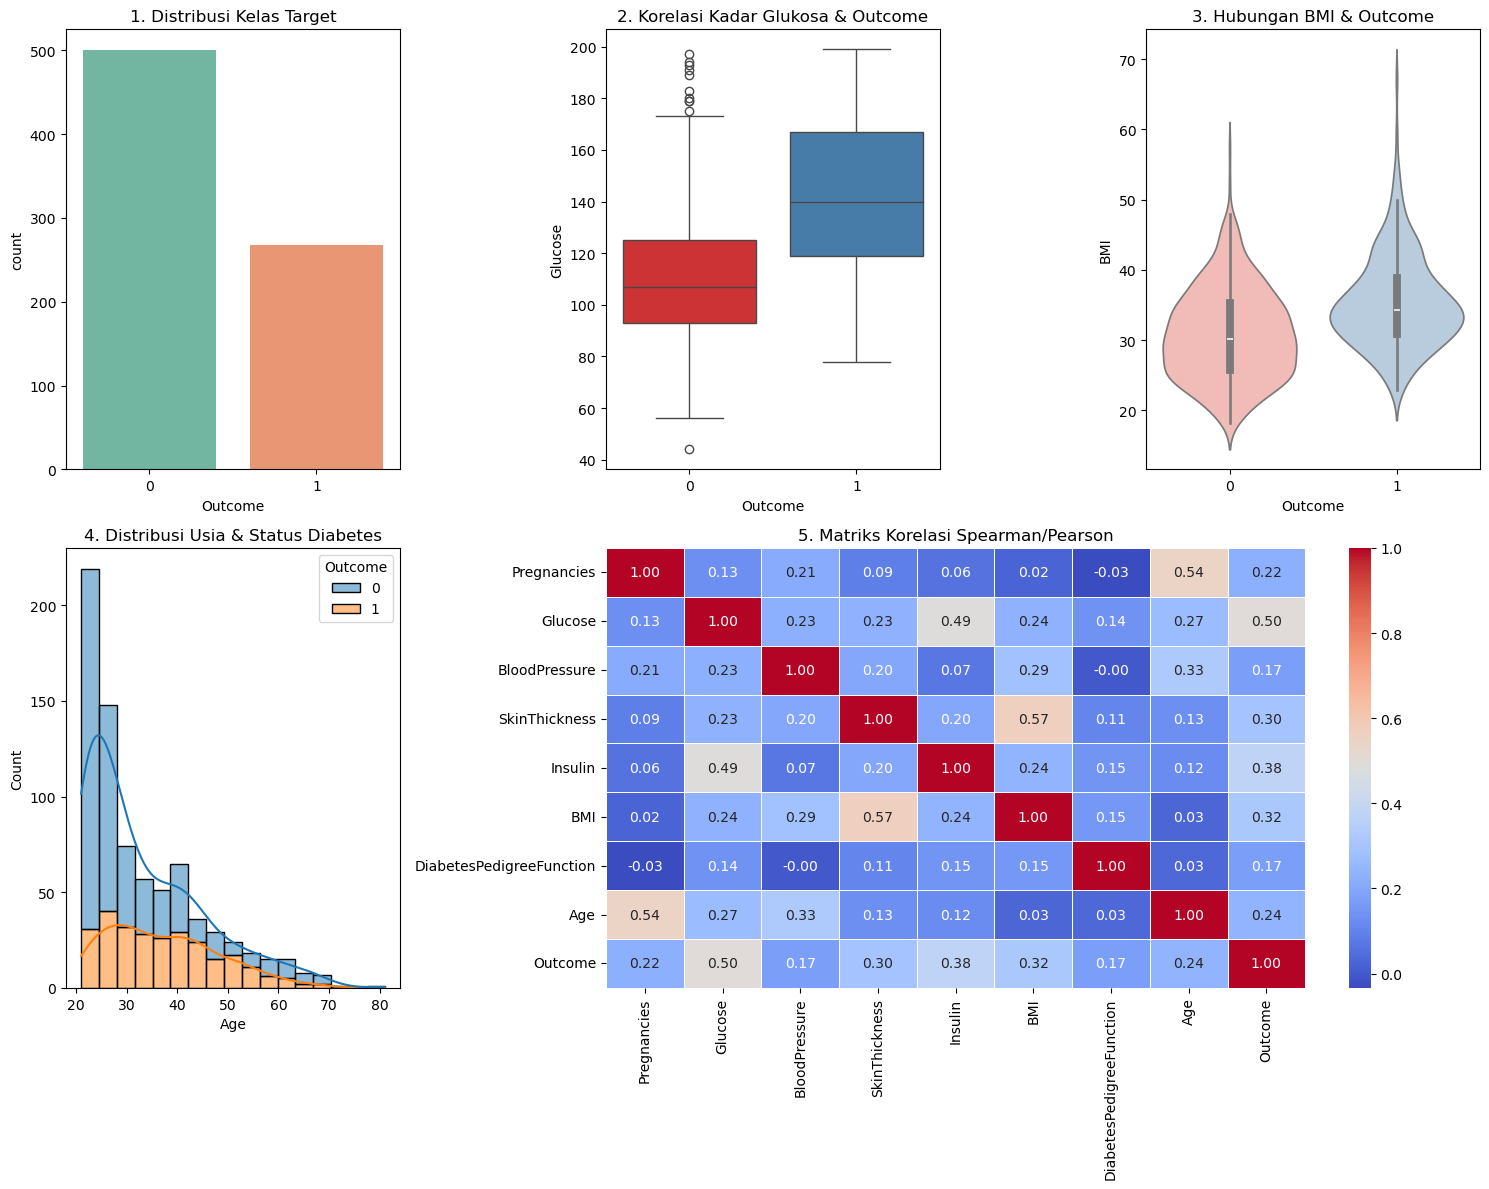

In [4]:
# Mengatur ukuran kanvas gambar grafik
plt.figure(figsize=(15, 12))

# 1. Distribusi Kelas Target
plt.subplot(2, 3, 1)
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('1. Distribusi Kelas Target')

# 2. Korelasi Kadar Glukosa & Outcome
plt.subplot(2, 3, 2)
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set1')
plt.title('2. Korelasi Kadar Glukosa & Outcome')

# 3. Hubungan BMI & Outcome
plt.subplot(2, 3, 3)
sns.violinplot(x='Outcome', y='BMI', data=df, palette='Pastel1')
plt.title('3. Hubungan BMI & Outcome')

# 4. Distribusi Usia & Status Diabetes
plt.subplot(2, 3, 4)
sns.histplot(data=df, x='Age', hue='Outcome', multiple='stack', kde=True)
plt.title('4. Distribusi Usia & Status Diabetes')

# 5. Matriks Korelasi Spearman/Pearson
plt.subplot(2, 3, (5, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('5. Matriks Korelasi Spearman/Pearson')

plt.tight_layout()
plt.show()

In [5]:
# Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Membagi data menjadi 80% Training dan 20% Testing secara seimbang (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Lakukan Scaling (Standarisasi) agar performa algoritma berbasis jarak (KNN) maksimal
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ukuran Data Training: {X_train.shape}")
print(f"Ukuran Data Testing: {X_test.shape}")

Ukuran Data Training: (614, 8)
Ukuran Data Testing: (154, 8)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Inisialisasi Model
knn_model = KNeighborsClassifier(n_neighbors=5)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Training Model
knn_model.fit(X_train_scaled, y_train)
dt_model.fit(X_train, y_train) # Decision tree tidak sensitif skala data, pakai data asli

# Prediksi Data Test
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_dt = dt_model.predict(X_test)

# Rekap Performa ke dalam DataFrame
metrics_summary = {
    "Model": ["K-Nearest Neighbors (KNN)", "Decision Tree"],
    "Accuracy": [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_dt)],
    "Precision": [precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_dt)],
    "Recall": [recall_score(y_test, y_pred_knn), recall_score(y_test, y_pred_dt)],
    "F1-Score": [f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_dt)]
}

df_perf = pd.DataFrame(metrics_summary)
print("=== HASIL EVALUASI MODEL ===")
print(df_perf.to_string(index=False))

=== HASIL EVALUASI MODEL ===
                    Model  Accuracy  Precision   Recall  F1-Score
K-Nearest Neighbors (KNN)  0.811688   0.735849 0.722222  0.728972
            Decision Tree  0.824675   0.754717 0.740741  0.747664
